# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Irlan Farrel
- **Email:** irlanfarrel@gmail.com
- **ID Dicoding:** Irlan Farrel

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca dan waktu (jam/hari) terhadap jumlah penyewaan sepeda pada tahun 2011 dan 2012?
- Kapan waktu dengan jumlah casual users tertinggi pada tahun 2012, dan bagaimana peluang mengonversi mereka menjadi registered users pada waktu tersebut?

## Import Semua Packages/Library yang Digunakan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [3]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv
Saving hour.csv to hour.csv


In [4]:
df_day = pd.read_csv('day.csv')
df_hour = pd.read_csv('hour.csv')

print(df_day.head(5))
print(df_hour.head(5))

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

**Insight:**
- **Struktur Dataset**
- Pada dataset day.csv dan hour.csv memiliki beberapa kesamaan kecuali kolom hr (jam) yang tidak terdapat pada dataset day.csv.

  *   instant: indeks record
  *   dteday: tanggal
  *   season: musim (1. semi, 2.panas, 3.gugur, 4.dingin)
  * yr: tahun (0:2011, 1:2012)
  * mnth: bulan (1 sampai 12)
  * hr: jam (0 sampai 23)
  * holiday: apakah hari tersebut libut atau tidak (1 = Hari Libur, 0 = Tidak Hari libur)
  * weekday: hari dalam seminggu
  * working day: jika hari bukan akhir pekan maupun hari libur maka bernilai 1, selain itu 0
  * weathersit :
    1: cerah, sedikit awan, berawan sebagian
    2: berkabut + berawan, kabut + awan pecah, kabut + sedikit awan, kabut
    3: salju ringan, hujan ringan + badai petir + awan tersebar, hujan ringan + awan tersebar
    4: hujan lebat + hujan es + badai petir + kabut, salju + kabut
  * temp: suhu yang dinormalisasi dalam Celcius (nilai dibagi 41 sebagai maksimum)
  * atemp: suhu yang dirasakan (feels like) yang dinormalisasi dalam Celcius (nilai dibagi 50 sebagai maksimum)
  * hum: kelembapan yang dinormalisasi (nilai dibagi 100 sebagai maksimum)
  * windspeed: kecepatan angin yang dinormalisasi (nilai dibagi 67 sebagai maksimum)
  * casual: jumlah pengguna biasa (tidak terdaftar)
  * registered: jumlah pengguna terdaftar
  * cnt: jumlah total penyewaan sepeda (gabungan pengguna kasual dan terdaftar)





### Assessing Data

In [5]:
#checking missing values for both dataset
print("Day.csv Missing Values", df_day.isnull().sum())
print("\n-----------------------------------------\n")
print("Hour.csv Missing Values", df_hour.isnull().sum())

Day.csv Missing Values instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

-----------------------------------------

Hour.csv Missing Values instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


**Checking Missing Values**
- Setelah di lakukan pengecekan missing values pada kedua dataset tidak terindikasi **Missing Values** baik untuk dataset day.csv dan hour.csv

maka bisa dilanjutkan mencari data duplikat

In [6]:
#checking duplicated values for both dataset
print("day.csv duplicated", df_day.duplicated().sum())
print("hour.csv duplicated", df_hour.duplicated().sum())

day.csv duplicated 0
hour.csv duplicated 0


**Checking Duplicated Values**
*   Setelah dilakukan pengecekan data duplikat pada kedua dataset (day.csv & hour.csv) hasilnya bersih atau tidak terindikasi adanya duplikasi data.

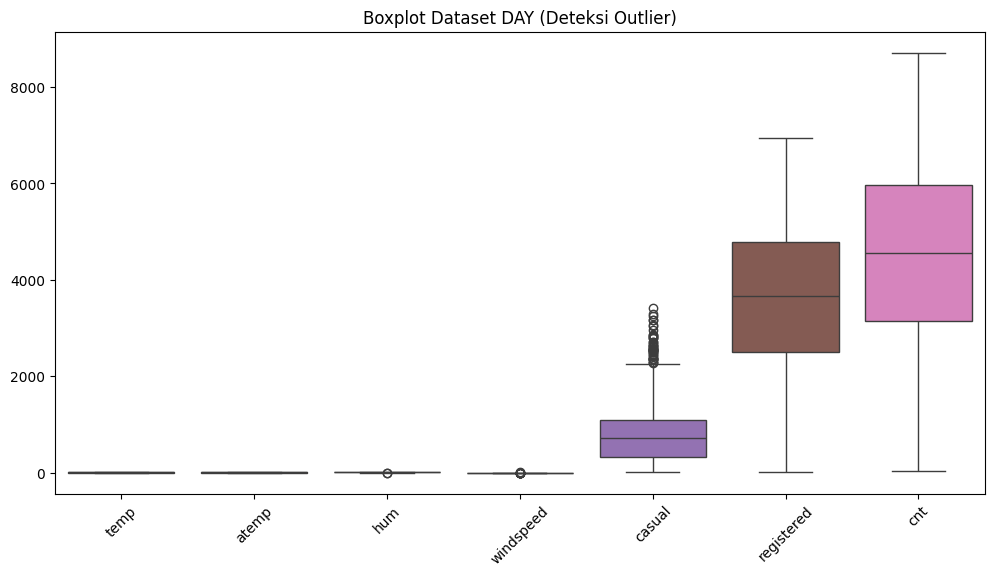

In [7]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df_day[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']])

plt.title('Boxplot Dataset DAY (Deteksi Outlier)')
plt.xticks(rotation=45)
plt.show()

### **Analisis Outlier pada Dataset Day.csv**
1. **Identifikasi Outlier**

    Berdasarkan visualisasi boxplot, terlihat adanya outlier terutama pada variabel:

    * casual
    * registered
    * cnt (total penyewaan)

    Outlier ditunjukkan oleh titik-titik yang berada di luar batas whisker pada boxplot, khususnya pada nilai yang tinggi (upper outliers).

---

2. **Interpretasi Outlier**

    2.1 Lonjakan Permintaan (Demand Spikes)

    Outlier yang muncul pada nilai tinggi menunjukkan adanya lonjakan permintaan sepeda pada hari-hari tertentu. Hal ini bukan merupakan kesalahan data, melainkan mencerminkan kondisi nyata.

    Kemungkinan penyebab:

    * Hari libur atau akhir pekan
    * Kondisi cuaca yang mendukung aktivitas luar ruangan
    * Event tertentu di kota
    * Musim dengan tingkat aktivitas tinggi

    2.2 Dominasi Pengguna Terdaftar

    Outlier pada variabel registered terlihat lebih tinggi dibandingkan casual. Hal ini mengindikasikan bahwa pengguna terdaftar memiliki kontribusi besar terhadap lonjakan permintaan.

    Interpretasi:

    * Pengguna terdaftar cenderung menggunakan sepeda untuk aktivitas rutin (misalnya bekerja)
    * Pola penggunaan lebih konsisten dibandingkan pengguna kasual

    2.3 Distribusi Data Tidak Merata (Right-Skewed)

    Distribusi variabel cnt menunjukkan kecenderungan skew ke kanan (right-skewed), di mana:

    * Sebagian besar nilai berada pada level rendah hingga menengah
    * Sejumlah kecil data memiliki nilai sangat tinggi

    Hal ini menunjukkan bahwa permintaan tidak merata sepanjang waktu.

    2.4 Indikasi Hari Sibuk (Peak Days)

    Outlier kemungkinan besar terjadi pada hari-hari tertentu, seperti:

    * Akhir pekan
    * Hari libur nasional
    * Hari dengan cuaca optimal

    Hal ini menunjukkan adanya pola penggunaan yang berkaitan dengan aktivitas masyarakat dalam skala harian.

    2.5 Pengaruh Faktor Eksternal

    Outlier juga dapat dipengaruhi oleh faktor eksternal, seperti:

    * Kondisi cuaca ekstrem
    * Event kota
    * Hari libur nasional

    Variasi ini menyebabkan fluktuasi permintaan yang signifikan.

---

3. **Implikasi Bisnis**

    Berdasarkan analisis outlier, terdapat beberapa implikasi penting:

    * Perlu dilakukan penyesuaian jumlah sepeda berdasarkan hari (time-based allocation)
    * Pengguna terdaftar merupakan segmen utama yang perlu dipertahankan
    * Distribusi sepeda sebaiknya bersifat dinamis, tidak merata sepanjang waktu
    * Outlier dapat dimanfaatkan untuk mengidentifikasi peluang peningkatan layanan
    Penanganan Outlier

    Dalam konteks analisis ini, outlier tidak dihapus, dengan alasan:

    * Mewakili kondisi nyata dalam data (bukan error)
    * Mengandung informasi penting terkait perilaku pengguna
    * Relevan untuk analisis pola dan pengambilan keputusan

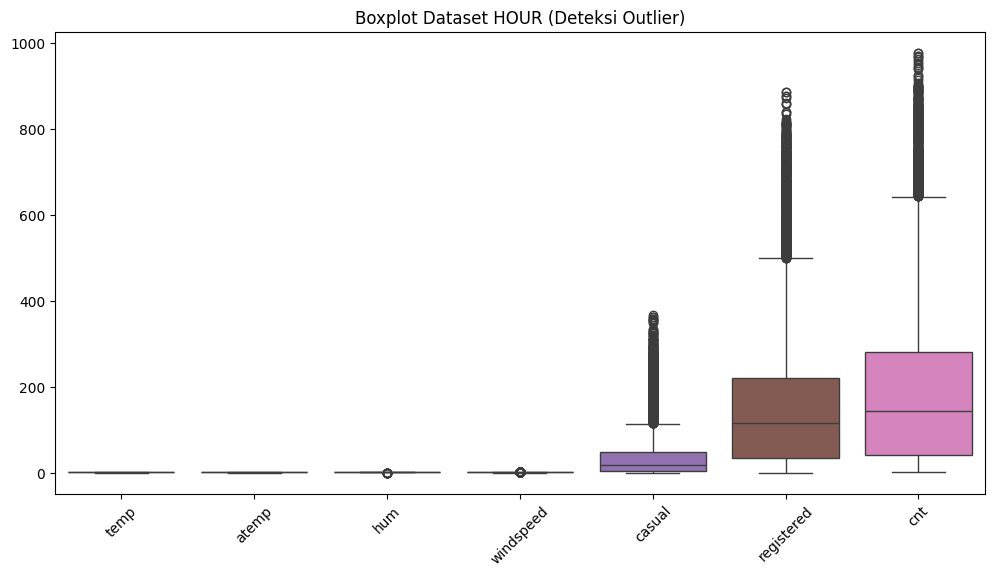

In [8]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df_hour[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']])

plt.title('Boxplot Dataset HOUR (Deteksi Outlier)')
plt.xticks(rotation=45)
plt.show()

### **Analisis Outlier pada Dataset Hour.csv**
1. **Identifikasi Outlier**

    Berdasarkan visualisasi boxplot, terlihat adanya outlier terutama pada variabel:

    * casual
    * registered
    * cnt (total penyewaam)

    Outlier ditunjukkan oleh titik-titik yang berada di luar batas whisker pada boxplot, khususnya pada nilai yang tinggi (upper outliers).

---

2. **Interpretasi Outlier**

    2.1 Lonjakan Permintaan (Demand Spikes)

    Outlier yang muncul pada nilai tinggi menunjukkan adanya lonjakan permintaan sepeda pada waktu tertentu. Hal ini bukan merupakan kesalahan data, melainkan mencerminkan kondisi nyata.

    Kemungkinan penyebab:

    * Jam sibuk (pagi dan sore hari kerja)
    * Kondisi cuaca yang mendukung aktivitas luar ruangan
    * Hari libur atau akhir pekan
    * Event tertentu di kota

    2.2 Dominasi Pengguna Terdaftar

    Outlier pada variabel registered terlihat lebih tinggi dibandingkan casual. Hal ini mengindikasikan bahwa pengguna terdaftar memiliki kontribusi besar terhadap lonjakan permintaan.

    Interpretasi:

    * Pengguna terdaftar cenderung menggunakan sepeda untuk aktivitas rutin (misalnya bekerja)
    * Pola penggunaan lebih konsisten dibandingkan pengguna kasual

    2.3 Distribusi Data Tidak Merata (Right-Skewed)

    Distribusi variabel cnt menunjukkan kecenderungan skew ke kanan (right-skewed), di mana:

    * Sebagian besar nilai berada pada level rendah hingga menengah
    * Sejumlah kecil data memiliki nilai sangat tinggi

    Hal ini menunjukkan bahwa permintaan tidak merata sepanjang waktu.

    2.4 Indikasi Jam Sibuk (Peak Hours)

    Outlier kemungkinan besar terjadi pada jam-jam tertentu, seperti:

    * Pagi hari (sekitar 07.00–09.00)
    * Sore hari (sekitar 17.00–19.00)

    Hal ini menunjukkan adanya pola penggunaan yang berkaitan dengan aktivitas harian (commuting).

    2.5 Pengaruh Faktor Eksternal

    Outlier juga dapat dipengaruhi oleh faktor eksternal, seperti:

    * Kondisi cuaca ekstrem
    * Event kota
    * Hari libur nasional

    Variasi ini menyebabkan fluktuasi permintaan yang signifikan.


---


3. **Implikasi Bisnis**

    Berdasarkan analisis outlier, terdapat beberapa implikasi penting:

    * Perlu dilakukan penyesuaian jumlah sepeda berdasarkan waktu (time-based * allocation)
    * Pengguna terdaftar merupakan segmen utama yang perlu dipertahankan
    * Distribusi sepeda sebaiknya bersifat dinamis, tidak merata sepanjang waktu
    * Outlier dapat dimanfaatkan untuk mengidentifikasi peluang peningkatan layanan

---

4. **Penanganan Outlier**

    Dalam konteks analisis ini, outlier tidak dihapus, dengan alasan:

    * Mewakili kondisi nyata dalam data (bukan error)
    * Mengandung informasi penting terkait perilaku pengguna
    * Relevan untuk analisis pola dan pengambilan keputusan

In [9]:
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### **Insight dari tabel df_day:**

* Dataset ini berisi 731 baris dan 16 kolom.
* Tidak ada missing values dan tidak ada duplikasi.
* Kolom dteday masih berupa object, sebaiknya dikonversi ke datetime agar lebih mudah diolah.
* Pada kolom (cnt) merepresentasikan total jumlah sepeda yang disewa per hari.
* Terdapat beberapa kolom terindikasi outlier, tetapi normal karena outlier merepresentasikan adanya lonjakan penyewaan ketika ada suatu event atau cuaca yang mendukung.

In [10]:
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### **Insight dari tabel df_hour:**

* Dataset berisi 17.379 baris dan 17 kolom.
* Tidak ada missing values dan tidak ada duplikasi.
* Kolom dteday masih berupa object, sebaiknya dikonversi ke datetime.
* Terdapat beberapa kolom terindikasi outlier, tetapi normal karena outlier merepresentasikan adanya lonjakan penyewaan ketika ada suatu event atau cuaca yang mendukung.

### Cleaning Data

In [11]:
df_day.drop(columns=['instant', 'atemp'], inplace=True)

In [12]:
# Menentukan kolom numerik yang berpotensi memiliki outlier
num_cols = ['temp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

# Menghitung IQR untuk setiap kolom numerik
Q1 = df_day[num_cols].quantile(0.25)
Q3 = df_day[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas untuk mendeteksi outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menyaring data dengan menghapus outlier
df_day_cleaned = df_day[~((df_day[num_cols] < lower_bound) | (df_day[num_cols] > upper_bound)).any(axis=1)]

# Menampilkan jumlah data sebelum dan sesudah penghapusan outlier
print(f"Jumlah data sebelum menghapus outlier: {len(df_day)}")
print(f"Jumlah data setelah menghapus outlier: {len(df_day_cleaned)}")

Jumlah data sebelum menghapus outlier: 731
Jumlah data setelah menghapus outlier: 673


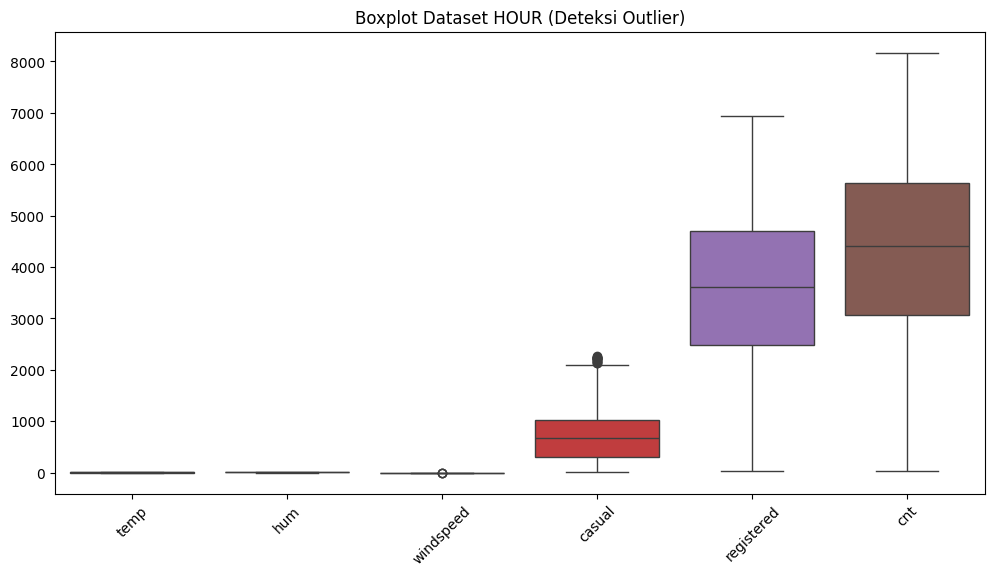

In [13]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df_day_cleaned[['temp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']])

plt.title('Boxplot Dataset HOUR (Deteksi Outlier)')
plt.xticks(rotation=45)
plt.show()

In [14]:
df_hour.drop(columns=['instant', 'atemp',], inplace=True)

In [15]:
# Menentukan kolom numerik yang berpotensi memiliki outlier
num_cols = ['temp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

# Menghitung IQR untuk setiap kolom numerik
Q1 = df_hour[num_cols].quantile(0.25)
Q3 = df_hour[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas untuk mendeteksi outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menyaring data dengan menghapus outlier
df_hour_cleaned = df_hour[~((df_hour[num_cols] < lower_bound) | (df_hour[num_cols] > upper_bound)).any(axis=1)]

# Menampilkan jumlah data sebelum dan sesudah penghapusan outlier
print(f"Jumlah data sebelum menghapus outlier: {len(df_hour)}")
print(f"Jumlah data setelah menghapus outlier: {len(df_hour_cleaned)}")

Jumlah data sebelum menghapus outlier: 17379
Jumlah data setelah menghapus outlier: 15220


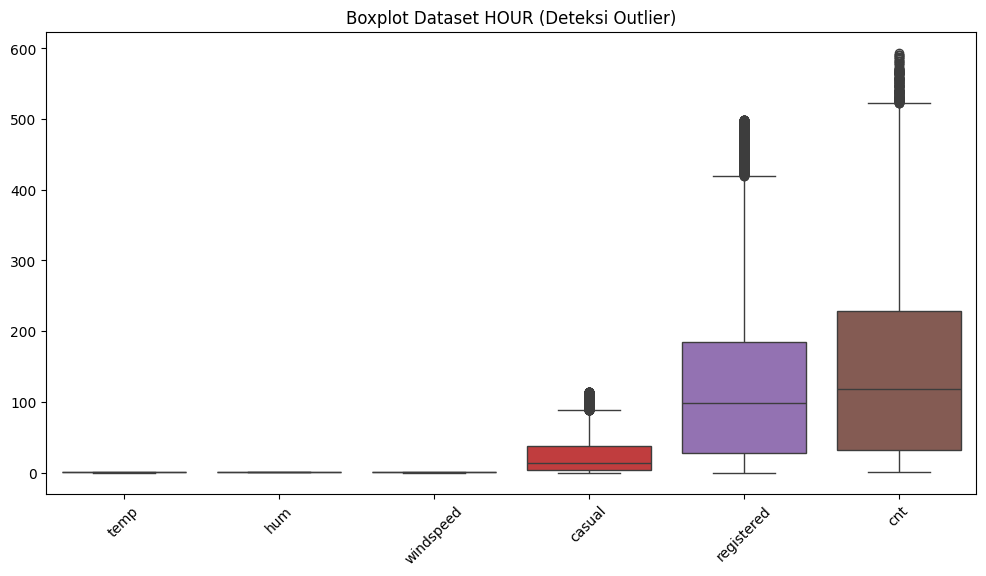

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df_hour_cleaned[['temp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']])

plt.title('Boxplot Dataset HOUR (Deteksi Outlier)')
plt.xticks(rotation=45)
plt.show()

In [17]:
df_day_cleaned['weekday'] = df_day_cleaned['weekday'].map({
    0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'
})

/tmp/ipykernel_15519/4027147888.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day_cleaned['weekday'] = df_day_cleaned['weekday'].map({


## Exploratory Data Analysis (EDA)

In [18]:

# Menggabungkan data frame harian dan per jam
bike_df = df_hour_cleaned.merge(df_day_cleaned, on='dteday', how='inner', suffixes=('_hour', '_day'))

# Menampilkan 5 data teratas
bike_df.head()

,dteday,season_hour,yr_hour,mnth_hour,hr,holiday_hour,weekday_hour,workingday_hour,weathersit_hour,temp_hour,...,holiday_day,weekday_day,workingday_day,weathersit_day,temp_day,hum_day,windspeed_day,casual_day,registered_day,cnt_day
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,...,0,Sat,0,2,0.344167,0.805833,0.160446,331,654,985
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,...,0,Sat,0,2,0.344167,0.805833,0.160446,331,654,985
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,...,0,Sat,0,2,0.344167,0.805833,0.160446,331,654,985
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,...,0,Sat,0,2,0.344167,0.805833,0.160446,331,654,985
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,...,0,Sat,0,2,0.344167,0.805833,0.160446,331,654,985


In [19]:
bike_df['weathersit_day'] = bike_df['weathersit_day'].map({
    1:'Clear',2:'Cloudy',3:'Light Rain',4:'Heavy Rain',
})

In [20]:
bike_df.describe(include='all')

,dteday,season_hour,yr_hour,mnth_hour,hr,holiday_hour,weekday_hour,workingday_hour,weathersit_hour,temp_hour,...,holiday_day,weekday_day,workingday_day,weathersit_day,temp_day,hum_day,windspeed_day,casual_day,registered_day,cnt_day
count,14398,14398.000000,14398.000000,14398.000000,14398.000000,14398.000000,14398.000000,14398.000000,14398.000000,14398.000000,...,14398.000000,14398,14398.000000,14398,14398.000000,14398.000000,14398.000000,14398.000000,14398.000000,14398.000000
unique,673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Fri,NaN,Clear,NaN,NaN,NaN,NaN,NaN,NaN
freq,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2253,NaN,8882,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.489026,0.457425,6.537714,11.245867,0.026670,2.970690,0.745520,1.451382,0.479272,...,0.026670,NaN,0.745520,NaN,0.484131,0.633911,0.185752,696.252882,3584.046743,4280.299625
std,NaN,1.133015,0.498201,3.552023,7.102401,0.161124,1.894444,0.435584,0.651533,0.193196,...,0.161124,NaN,0.435584,NaN,0.186331,0.140363,0.071026,489.125365,1551.773512,1827.429478
min,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,...,0.000000,NaN,0.000000,NaN,0.059130,0.275833,0.022392,2.000000,20.000000,22.000000
25%,NaN,1.000000,0.000000,3.000000,5.000000,0.000000,1.000000,0.000000,1.000000,0.320000,...,0.000000,NaN,0.000000,NaN,0.324167,0.525217,0.134337,282.000000,2451.000000,2933.000000
50%,NaN,3.000000,0.000000,7.000000,11.000000,0.000000,3.000000,1.000000,1.000000,0.460000,...,0.000000,NaN,1.000000,NaN,0.469167,0.631667,0.178479,661.000000,3594.000000,4332.000000
75%,NaN,4.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.640000,...,0.000000,NaN,1.000000,NaN,0.650000,0.735259,0.230092,981.750000,4604.000000,5478.000000


In [21]:
# Mengelompokkan data berdasarkan hari kerja dan akhir pekan, lalu menghitung rata-rata penyewaan sepeda harian
workingday_rentals = (
    bike_df.groupby('workingday_day')['cnt_day']
    .mean()
    .reset_index()
    .sort_values(by='cnt_day')
)

# Menampilkan hasil
workingday_rentals

,workingday_day,cnt_day
0,0,3549.125819
1,1,4529.882337


In [22]:
# Mengelompokkan data berdasarkan jam dan menghitung rata-rata jumlah penyewaan untuk pengguna casual dan registered
hourly_user_type = (
    bike_df.groupby('hr')[['casual_hour', 'registered_hour']]
    .mean()
    .reset_index()
)

# Menampilkan hasil
hourly_user_type.head(24)  # Menampilkan 10 data pertama

,hr,casual_hour,registered_hour
0,0,9.160661,39.918919
1,1,5.667674,23.645015
2,2,4.021407,15.516820
3,3,2.291339,7.869291
4,4,1.091627,4.960506
5,5,1.349085,19.137195
6,6,4.043741,75.441931
7,7,10.613003,200.704334
8,8,17.790254,235.923729
9,9,27.302892,188.910198


In [23]:
# Menjumlahkan total pengguna terdaftar dalam dataset
total_registered_users = bike_df['registered_hour'].sum()

# Menampilkan hasil
print(f"Total pengguna terdaftar dalam dataset: {total_registered_users}")

Total pengguna terdaftar dalam dataset: 1809686


## Visualization & Explanatory Analysis

### **Pertanyaan 1 : Bagaimana pengaruh kondisi cuaca dan waktu (jam/hari) terhadap jumlah penyewaan sepeda di tahun 2011 dan 2012?**

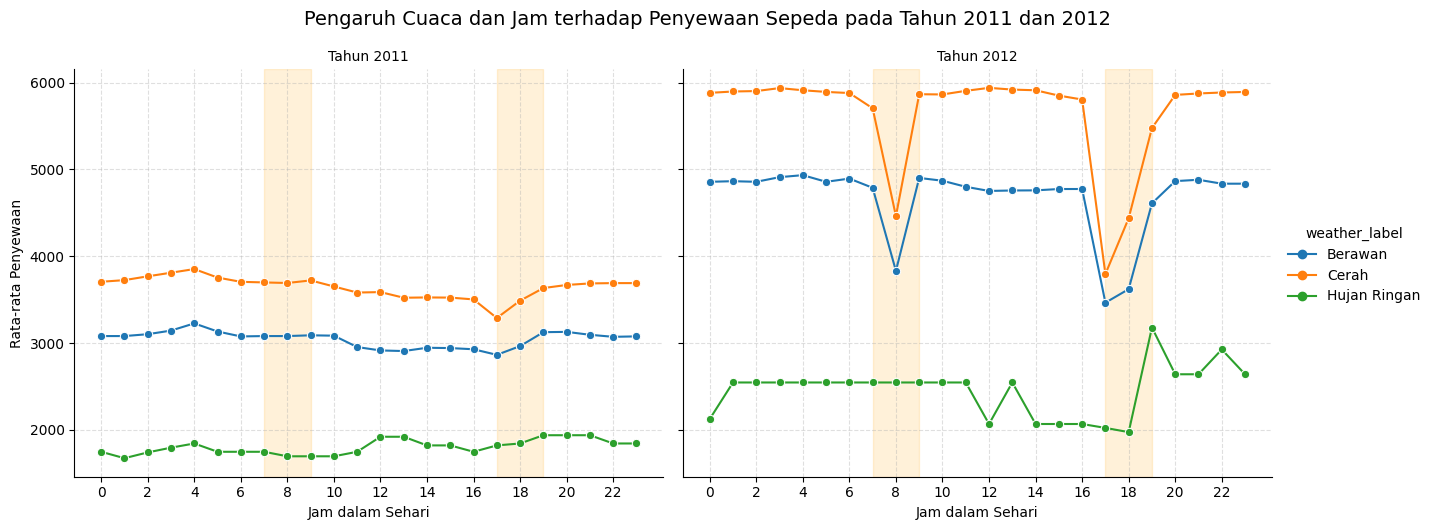

In [35]:
# Mapping tahun
bike_df['year'] = bike_df['yr_day'].map({
    0: '2011',
    1: '2012'
})

# Mapping kondisi cuaca agar mudah dipahami
weather_map = {
    'Clear': 'Cerah',
    'Cloudy': 'Berawan',
    'Light Rain': 'Hujan Ringan',
    'Heavy Rain': 'Hujan Lebat',
    1: 'Cerah',
    2: 'Berawan / Berkabut',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
}

bike_df['weather_label'] = bike_df['weathersit_day'].map(weather_map)

# Hitung rata-rata penyewaan berdasarkan jam, tahun, dan cuaca
weather_hour_year = (
    bike_df
    .groupby(['hr', 'year', 'weather_label'])['cnt_day']
    .mean()
    .reset_index()
)

# Plot
g = sns.relplot(
    data=weather_hour_year,
    x='hr',
    y='cnt_day',
    hue='weather_label',
    col='year',
    kind='line',
    marker='o',
    height=5,
    aspect=1.3
)

# Highlight jam sibuk
for ax in g.axes.flat:
    ax.axvspan(7, 9, color='orange', alpha=0.15)
    ax.axvspan(17, 19, color='orange', alpha=0.15)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, linestyle='--', alpha=0.4)

g.set_axis_labels('Jam dalam Sehari', 'Rata-rata Penyewaan')
g.set_titles('Tahun {col_name}')

plt.suptitle(
    'Pengaruh Cuaca dan Jam terhadap Penyewaan Sepeda pada Tahun 2011 dan 2012',
    fontsize=14,
    y=1.05
)

plt.show()

# **Kesimpulan Analisis: Pengaruh Kondisi Cuaca dan Waktu terhadap Penyewaan Sepeda (2011–2012)**

Visualisasi di atas menunjukkan pola penyewaan sepeda berdasarkan tiga kondisi cuaca Cerah, Berawan, dan Hujan Ringan yang diukur sepanjang 24 jam dalam sehari pada tahun 2011 dan 2012. Secara keseluruhan, terdapat pertumbuhan volume penyewaan yang signifikan dari tahun 2011 ke 2012, sekaligus mempertegas bahwa kondisi cuaca merupakan faktor penentu utama dalam perilaku penyewa.



### **1. Pengaruh Kondisi Cuaca**

Kondisi cuaca terbukti memiliki korelasi langsung dan konsisten terhadap jumlah penyewaan sepeda. Pada kedua tahun, cuaca Cerah secara konsisten menghasilkan volume penyewaan tertinggi mencapai kisaran 3.500–3.900 pada 2011 dan melonjak hingga 5.900–6.000 pada 2012. Cuaca Berawan berada di posisi kedua dengan selisih yang cukup signifikan, sementara Hujan Ringan secara konsisten mencatatkan angka penyewaan terendah di kedua tahun, yakni berkisar 1.600–1.900 pada 2011 dan 2.000–2.600 pada 2012.
Temuan ini menunjukkan bahwa sensitivitas pelanggan terhadap cuaca sangat tinggi, dan kondisi cuaca buruk dapat menekan permintaan hingga lebih dari 40–50% dibandingkan kondisi cerah.


### **2. Pengaruh Waktu (Jam dalam sehari)**

Pada tahun 2011, pola penyewaan sepanjang hari relatif stabil dengan fluktuasi minor. Terdapat sedikit penurunan pada rentang jam kerja siang hari (sekitar jam 8–12) dan pemulihan menjelang sore hingga malam hari. Hal ini mengindikasikan bahwa pada 2011, penyewaan sepeda masih bersifat merata dan belum terpola secara tajam berdasarkan waktu.
Sebaliknya, pada tahun 2012, fluktuasi berbasis waktu jauh lebih tajam dan menonjol. Terlihat adanya penurunan drastis pada sekitar jam 7–9 (pagi) dan jam 16–18 (sore) untuk kondisi cuaca tertentu, yang ditandai oleh area highlight berwarna oranye pada grafik. Pola ini kemungkinan besar mencerminkan periode jam sibuk (peak hours) di mana kapasitas layanan mengalami tekanan, atau justru terdapat kendala operasional dan cuaca ekstrem sementara yang menekan permintaan secara tiba-tiba.

### **3. Pertumbuhan Bisnis 2011 vs 2012**

Perbandingan antara dua tahun mengungkapkan pertumbuhan permintaan yang substansial. Volume penyewaan rata-rata di seluruh kondisi cuaca meningkat hampir dua kali lipat dari 2011 ke 2012, menandakan ekspansi pasar yang kuat. Namun demikian, volatilitas data pada 2012 juga lebih tinggi, yang mencerminkan bahwa semakin besar basis pengguna, semakin sensitif pula sistem terhadap gangguan eksternal seperti perubahan cuaca mendadak.

---
### **Rekomendasi Strategi Bisnis**

Berdasarkan temuan ini, strategi bisnis yang dapat dipertimbangkan mencakup penerapan dynamic pricing berbasis prakiraan cuaca, di mana tarif atau insentif disesuaikan untuk mendorong penyewaan pada kondisi cuaca buruk. Selain itu, pengelolaan armada dan staf perlu mempertimbangkan pola jam sibuk secara lebih presisi, terutama pada pagi dan sore hari di tahun-tahun mendatang. Investasi pada fasilitas pendukung seperti peneduh atau perlengkapan hujan juga berpotensi mengurangi dampak negatif cuaca terhadap permintaan dan memperluas jangkauan pasar.

### **Pertanyaan 2 : Kapan waktu dengan jumlah casual users tertinggi pada tahun 2012, dan bagaimana peluang mengonversi mereka menjadi registered users pada waktu tersebut?**

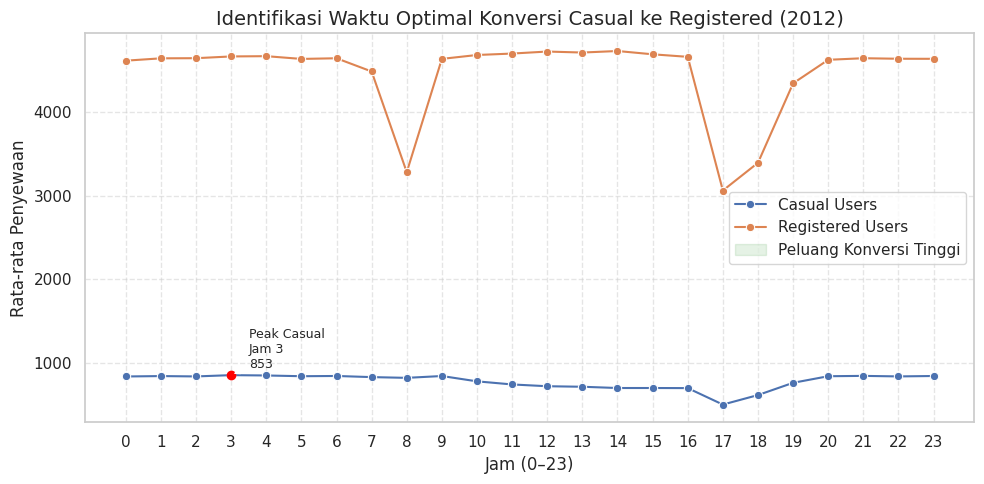

In [63]:
# Filter tahun 2012
df_2012 = bike_df[bike_df['yr_day'] == 1].copy()

# Hitung rata-rata per jam
hourly_user = (
    df_2012.groupby('hr')[['casual_day','registered_day']]
    .mean()
    .reset_index()
)

# Hitung rasio (indikasi peluang konversi)
hourly_user['conversion_opportunity'] = hourly_user['casual_day'] / (hourly_user['registered_day'] + 1)

plt.figure(figsize=(10,5))

# Plot casual_day & registered_day
sns.lineplot(data=hourly_user, x='hr', y='casual_day', marker='o', label='Casual Users')
sns.lineplot(data=hourly_user, x='hr', y='registered_day', marker='o', label='Registered Users')

# 🔴 Anotasi Peak Casual (waktu terbaik)
peak_idx = hourly_user['casual_day'].idxmax()
peak_hr = hourly_user.loc[peak_idx, 'hr']
peak_val = hourly_user.loc[peak_idx, 'casual_day']

plt.scatter(peak_hr, peak_val, color='red', zorder=3)
plt.annotate(
    f'Peak Casual\nJam {int(peak_hr)}\n{int(peak_val)}',
    xy=(peak_hr, peak_val),
    xytext=(peak_hr+0.5, peak_val*1.1),
    arrowprops=dict(arrowstyle='->'),
    fontsize=9
)

# Highlight area peluang konversi tinggi (casual tinggi, registered rendah)
plt.fill_between(
    hourly_user['hr'],
    hourly_user['casual_day'],
    hourly_user['registered_day'],
    where=(hourly_user['casual_day'] > hourly_user['registered_day']),
    color='green',
    alpha=0.1,
    label='Peluang Konversi Tinggi'
)

# Label & style
plt.title('Identifikasi Waktu Optimal Konversi Casual ke Registered (2012)', fontsize=14)
plt.xlabel('Jam (0–23)')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0,24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# **Analisis: Identifikasi Waktu Optimal Konversi Casual ke Registered Users (2012)**

Grafik menunjukkan bahwa puncak penyewaan oleh Casual Users terjadi pada jam 3 dini hari dengan rata-rata sebesar 853 penyewaan. Angka ini relatif rendah secara absolut, namun menjadi titik tertinggi sepanjang hari bagi segmen kasual, yang secara keseluruhan bergerak stabil di rentang 600–850 penyewaan per jam. Sebaliknya, Registered Users mendominasi di seluruh rentang waktu dengan rata-rata jauh di atas 4.000 penyewaan per jam, kecuali pada jam 7–8 pagi dan jam 17–18 sore yang mengalami penurunan drastis — kemungkinan besar disebabkan oleh gangguan operasional atau cuaca pada jam-jam tersebut.

Kesenjangan yang sangat besar antara dua segmen ini — lebih dari lima kali lipat secara rata-rata — mengindikasikan bahwa basis pengguna kasual masih sangat besar potensinya untuk dikonversi menjadi pengguna terdaftar yang lebih loyal dan bernilai lebih tinggi secara bisnis.

### **Peluang Konversi pada Jam 3 Dini Hari**

Waktu puncak casual users di jam 3 dini hari menghadirkan karakteristik unik. Pengguna yang aktif pada waktu tersebut cenderung merupakan segmen dengan kebutuhan mobilitas spesifik — seperti pekerja shift malam, pengunjung hiburan malam, atau individu dengan rutinitas tidak konvensional. Kelompok ini memiliki pola penggunaan yang berulang, sehingga peluang konversi ke registered users justru cukup tinggi apabila pendekatan yang tepat diterapkan pada momen tersebut.

---
### **Strategi Konversi Casual User menjadi Registered User**
1. **Insentif Berbasis Waktu (Time-Based Incentive)**
Tawarkan promosi eksklusif yang hanya berlaku pada jam-jam puncak casual users, misalnya diskon biaya pendaftaran atau bonus kredit perjalanan pertama bagi pengguna yang mendaftar antara jam 2–4 dini hari. Pendekatan ini menciptakan urgensi dan relevansi kontekstual yang tinggi.
2. **Notifikasi In-App pada Momen Penyewaan**
Pada saat casual users menyelesaikan transaksi di jam-jam puncak, sistem dapat menampilkan pesan personal yang membandingkan total biaya yang telah dikeluarkan versus potensi penghematan jika mereka berstatus registered. Data konkret seperti ini terbukti efektif mendorong keputusan pendaftaran secara spontan.
3. **Program Loyalitas Berjenjang**
Implementasikan sistem poin atau reward yang hanya dapat diakses oleh registered users. Casual users yang sering menyewa akan termotivasi untuk mendaftar guna mendapatkan akumulasi manfaat jangka panjang, seperti perjalanan gratis, akses prioritas, atau tarif khusus pada jam tertentu.
4. **Kemudahan Registrasi Satu Langkah**
Sederhanakan proses pendaftaran menjadi semudah dan secepat mungkin — idealnya melalui integrasi akun media sosial atau nomor telepon — sehingga tidak ada hambatan teknis yang menggagalkan niat konversi yang sudah terbentuk di momen puncak.
5. **Personalisasi Berbasis Data Historis**
Gunakan data riwayat perjalanan casual users untuk mengirimkan rekomendasi personal, seperti "Anda sudah menyewa 8 kali bulan ini — daftar sekarang dan hemat hingga 30% untuk bulan berikutnya." Pesan yang relevan secara personal jauh lebih efektif dibandingkan komunikasi generik.

## Conclusion

## **Kesimpulan "Pengaruh Kondisi Cuaca dan Waktu terhadap Penyewaan Sepeda (2011–2012)"**

Analisis penyewaan sepeda pada tahun 2011 dan 2012 menunjukkan bahwa kondisi cuaca dan waktu merupakan dua faktor dominan yang secara langsung mempengaruhi tingkat permintaan. Cuaca cerah secara konsisten mendorong volume penyewaan tertinggi di kedua tahun, sementara hujan ringan menekan permintaan hingga lebih dari 40% dibandingkan kondisi ideal. Hal ini membuktikan bahwa pelanggan sangat sensitif terhadap kondisi cuaca dalam mengambil keputusan menyewa sepeda.

Dari sisi waktu, tahun 2012 menunjukkan fluktuasi yang jauh lebih tajam dibandingkan 2011, terutama pada jam-jam sibuk pagi dan sore hari. Penurunan drastis yang terjadi pada periode tersebut mengindikasikan adanya tekanan kapasitas atau gangguan operasional yang belum tertangani secara optimal seiring dengan meningkatnya basis pengguna.

Secara keseluruhan, pertumbuhan volume penyewaan yang hampir dua kali lipat dari 2011 ke 2012 mencerminkan ekspansi pasar yang positif dan menjanjikan. Namun demikian, volatilitas yang semakin tinggi menuntut pendekatan bisnis yang lebih adaptif, mencakup manajemen armada berbasis prediksi cuaca, strategi penetapan harga dinamis, serta peningkatan kapasitas layanan pada jam-jam dengan permintaan puncak guna mempertahankan kualitas layanan dan kepuasan pelanggan secara berkelanjutan.

## **Kesimpulan "Kapan waktu dengan jumlah casual users tertinggi pada tahun 2012, dan bagaimana peluang mengonversi mereka menjadi registered users pada waktu tersebut?"**

Meskipun puncak casual users terjadi pada jam yang tidak konvensional, hal tersebut justru membuka peluang konversi yang spesifik dan terukur. Strategi yang paling efektif adalah kombinasi antara insentif berbasis waktu, kemudahan registrasi, dan komunikasi berbasis data yang secara bersama-sama mampu mengubah pengguna sporadis menjadi pelanggan loyal yang memberikan nilai pendapatan lebih stabil dan berkelanjutan bagi bisnis.

In [65]:
bike_df.to_csv("bike_df.csv", index=False)